In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATA_PATH: str = "data.csv"

LAMBDA = 0.2
LOOKBACK_WINDOW = 20

STANDARDIZATION_METHODS = ['rank', "zscore"]

STRATIFICATION_N = 5
RISK_FREE_RATE = 0.03

In [3]:
def load_data(data_path: str = DATA_PATH) -> pd.DataFrame:
    """读取数据集"""
    df = pd.read_csv(data_path)

    df = df.dropna(subset=["date", "order_book_id"])

    # 将独立变量0值改为Nan并撇去变量全为Nan的行
    df[df.columns.drop('pct_rate')] = df[df.columns.drop('pct_rate')].replace(0, np.nan)
    df = df.dropna(subset=['buy_value', 'sell_value', 'buy_volume', 'sell_volume'], how='all')
    
    df['date'] = pd.to_datetime(df['date'])
    
    df = df.set_index(['date', 'order_book_id'])
    df = df.sort_index(level=['date', 'order_book_id'])

    return df

In [4]:
def calculate_factor(df: pd.DataFrame, lam: float = LAMBDA, hist_wdw: int = LOOKBACK_WINDOW) -> pd.DataFrame:
    """计算出a因子过渡值及最终值"""
    df_temp = df.swaplevel().sort_index()  # 暂时以股票做第一层以方便计算

    # 计算出过渡因子值
    df_temp['order_imbal'] = (df_temp['buy_value'] - df_temp['sell_value']) / (df_temp['buy_value'] + df_temp['sell_value'])
    df_temp['order_imbal'] = df_temp['order_imbal'].replace([np.inf, -np.inf], np.nan)

    def compute_group_factor(group: pd.DataFrame) -> pd.Series:
        order_imbals, returns = group['order_imbal'].values, group['pct_rate'].values
        out = np.full(len(group), np.nan)  # 默认返回Nan
        for i in range(hist_wdw - 1, len(group)):
            wdw_ord_imb, wdw_rets = order_imbals[i - hist_wdw + 1: i + 1], returns[i - hist_wdw + 1: i + 1]
            valid_rets_counts = np.sum(~np.isnan(wdw_rets))
            if valid_rets_counts < hist_wdw * 0.5: # Nan收益率值过多，代表性可能不足
                continue

            threshold = np.nanquantile(wdw_rets, lam)
            low_ret_mask = (wdw_rets <= threshold) & ~np.isnan(wdw_ord_imb)  # 低收益日中因子过渡值不能为Nan
            if low_ret_mask.any():
                out[i] = np.nanmean(wdw_ord_imb[low_ret_mask])

        return pd.Series(out, index=group.index)

    df_temp['factor'] = df_temp.groupby(level='order_book_id', group_keys=False).apply(compute_group_factor)

    df = df_temp.swaplevel().sort_index()  # 转变回数据集初始格式以便后续因子分析
    return df

In [5]:
def standardize_zscore(og_factors: pd.Series, n = 2.5) -> pd.Series:
    """
    因子载荷原始值标准化
    """
    # 计算中位数和MAD
    median = og_factors.median()
    mad = np.median(np.abs(og_factors - median))

    # 标准化
    factors = og_factors.clip(lower=median - n * mad, upper=median + n * mad)
    factors = (factors - factors.mean()) / factors.std()

    return factors

def standardize_rank(og_factors: pd.Series) -> pd.Series:
    """
    因子载荷排序值标准化
    """
    factors = og_factors.rank(method='average')
    factors = (factors - factors.mean()) / factors.std()

    return factors

def standardize_factor(df: pd.DataFrame, method: str = 'rank') -> pd.DataFrame:
    """因子值标准化 --- 横截面排名或zscore方式"""
    if method not in STANDARDIZATION_METHODS:
        return df

    std_factor = 'factor_ranked' if method == 'rank' else 'factor_zscore'
    if method == 'rank':
        df[std_factor] = df.groupby('date')['factor'].transform(standardize_rank)
        
    else:
        df[std_factor] = df.groupby('date')['factor'].transform(standardize_zscore)

    return df

In [6]:
def get_residual(x: pd.DataFrame, factor_col: str, control_col: str) -> pd.Series:
    """
    获取因子值的买卖金额残差
    """
    x = x.dropna(subset=[factor_col, control_col])
    if len(x) < 100:
        return pd.Series(np.nan, index=x.index)
    
    X = sm.add_constant(x[control_col])
    y = x[factor_col]

    model = sm.OLS(y, X).fit()
    return pd.Series(model.resid, index=x.index)

def neutralize_factor(df: pd.DataFrame, factor: str = 'factor_ranked') -> pd.DataFrame:
    """因子值中性化 --- 依流动性估测值"""
    df = df.copy()
    df['log_value'] = np.log(df['buy_value'] + df['sell_value'])

    df[factor + "_neu"] = df.groupby('date').apply(lambda x: get_residual(x, factor, 'log_value')).reset_index(level=0, drop=True)

    df = df.drop(columns=['log_value'])
    return df

In [7]:
def calculcate_ic_and_tstat(df: pd.DataFrame, factor_col: str) -> tuple[pd.Series, float]:
    """计算IC值和t-statistic"""
    df = df.copy()
    df['next_pct_rate'] = df.groupby(level='order_book_id')['pct_rate'].shift(-1)
    
    def ic_func(x):
        tmp = x[[factor_col, 'next_pct_rate']].dropna()
        if len(tmp) < 100:
            return np.nan

        return stats.spearmanr(tmp[factor_col], tmp['next_pct_rate'])[0]
    
    ic_series = df.groupby('date').apply(ic_func).dropna()

    ic_mean, ic_stdev = ic_series.mean(), ic_series.std()

    ir = ic_mean / ic_stdev if ic_stdev != 0 else  0

    tstat, p_val = stats.ttest_1samp(ic_series, 0)
    
    return ic_series, ic_mean, ic_stdev, ir, tstat, p_val

In [8]:
def stratify(x: pd.Series, num_groups: int) -> pd.Series:
    return pd.qcut(x.rank(method='first'), q = num_groups, labels=False, duplicates='drop') + 1

def stratified_backtest(df: pd.DataFrame, factor_col: str, num_groups: int = STRATIFICATION_N, risk_free_rate: float = RISK_FREE_RATE) -> tuple[pd.DataFrame, dict[pd.Series]]:
    df = df.copy()
    df['next_pct_rate'] = df.groupby(level='order_book_id')['pct_rate'].shift(-1)

    df['group'] = df.groupby('date')[factor_col].transform(lambda x: stratify(x, num_groups))
    group_returns = df.groupby(['date', 'group'])['next_pct_rate'].mean().unstack()

    group_performances, cum_returns = [], {}
    for group in range(1, num_groups + 1):
        annual_return = group_returns[group].mean() * 252
        annual_volatility = group_returns[group].std() * np.sqrt(252)

        sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility if annual_volatility != 0 else np.nan

        equity_curve = (1 + group_returns[group]).cumprod()

        max_drawdown = ((equity_curve.cummax() - equity_curve) / equity_curve.cummax()).max()

        group_performances.append({
            'Group': group,
            'Annual Return': annual_return,
            'Annual Volatiltiy': annual_volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Max Drawdown': max_drawdown
        })

        cum_returns[group] = equity_curve - 1
    
    return pd.DataFrame(group_performances).set_index('Group'), cum_returns

In [9]:
def plot_results(ic_info: dict[str, dict[str]], backtest_results: dict[str, tuple[pd.DataFrame, dict[pd.Series]]], 
                 factors: list[str]) -> None:
    """
    绘制结果图表
    """
    fig, axes = plt.subplots(len(factors), 4, figsize=(18, 5 * len(factors)))
    fig.suptitle('Factor Analysis Results', fontsize=14, y=1.01)

    for i, factor in enumerate(factors):
        group_stats, group_cum_rets = backtest_results[factor]
        ax_ic, ax_table, ax_cr, ax_gs = axes[i]

        # cumulative IC
        ic_series = ic_info[factor]['IC Series']
        cumulative_ic = ic_series.cumsum()
        ax_ic.plot(cumulative_ic.index, cumulative_ic.values, label='Cumulative IC')
        ax_ic.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax_ic.set_title(f'{factor} — cumulative IC')
        ax_ic.tick_params(axis='x', rotation=45)
        ax_ic.grid(True, alpha=0.5)

        # IC stats table
        ax_table.axis('off')
        ic = ic_info[factor]
        table_data = [[k, f'{v:.5f}'] for k, v in ic.items() if k != 'IC Series']
        table = ax_table.table(cellText=table_data, colLabels=['Metric', 'Value'],
                               loc='center', cellLoc='left')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(0.6, 1.8)
        ax_table.set_title(f'{factor} — IC stats')

        # cumulative returns
        for group, curve in group_cum_rets.items():
            ax_cr.plot(curve.index, curve.values, label=f'Group {group}')
        ax_cr.set_title(f'{factor} — cumulative returns')
        ax_cr.legend(fontsize=8)
        ax_cr.set_xlabel('')
        ax_cr.tick_params(axis='x', rotation=45)
        ax_cr.grid(True, alpha=0.5)

        # group stats bar chart
        stats = group_stats[factor] if isinstance(group_stats, dict) else group_stats
        x = np.arange(len(stats))
        width = 0.2
        for j, col in enumerate(stats.columns):
            ax_gs.bar(x + j * width, stats[col].values, width=width, label=col)
        ax_gs.set_xticks(x + width * (len(stats.columns) - 1) / 2)
        ax_gs.set_xticklabels([f'G{g}' for g in stats.index])
        ax_gs.axhline(0, color='black', linewidth=0.5)
        ax_gs.legend(fontsize=7)
        ax_gs.set_title(f'{factor} — group stats')

    plt.tight_layout()
    plt.show()

In [10]:
df = load_data()

In [11]:
df = calculate_factor(df)

In [12]:
df = standardize_factor(df)

In [13]:
df = neutralize_factor(df)

In [14]:
df

buy_volume     buy_value  sell_volume    sell_value  \
date       order_book_id                                                        
2020-01-02 000001.XSHE    84209533.0  1.414344e+09   68813654.0  1.156852e+09   
           000002.XSHE    50843277.0  1.679690e+09   50369763.0  1.662684e+09   
           000004.XSHE      705829.0  1.587629e+07    1079491.0  2.426869e+07   
           000005.XSHE     4971400.0  1.560739e+07    5442012.0  1.705402e+07   
           000006.XSHE     6488025.0  3.511604e+07    5987151.0  3.233682e+07   
...                              ...           ...          ...           ...   
2025-06-30 688799.XSHG     1406508.0  5.800410e+07    1767620.0  7.283469e+07   
           688800.XSHG     5851541.0  2.863658e+08    6998626.0  3.421055e+08   
           688819.XSHG     1788384.0  4.936817e+07    1576386.0  4.338212e+07   
           688981.XSHG    18172208.0  1.609141e+09   16180594.0  1.432188e+09   
           689009.XSHG     4815536.0  2.827421e+08    3667773.0  2.153004e+08   

                          pct_rate  order_imbal    factor  factor_ranked  \
date       order_book_id                                                   
2020-01-02 000001.XSHE    0.025532     0.100145       NaN            NaN   
           000002.XSHE    0.011809     0.005088       NaN            NaN   
           000004.XSHE   -0.011510    -0.209052       NaN            NaN   
           000005.XSHE    0.016182    -0.044292       NaN            NaN   
           000006.XSHE    0.007463     0.041202       NaN            NaN   
...                            ...          ...       ...            ...   
2025-06-30 688799.XSHG   -0.007451    -0.113350 -0.102069       0.997891   
           688800.XSHG    0.006341    -0.088691 -0.101975       1.001265   
           688819.XSHG    0.019838     0.064539 -0.068168       1.416350   
           688981.XSHG    0.014848     0.058183 -0.063171       1.449422   
           689009.XSHG    0.019644     0.135414 -0.126976       0.569307   

                          factor_ranked_neu  
date       order_book_id                     
2020-01-02 000001.XSHE                  NaN  
           000002.XSHE                  NaN  
           000004.XSHE                  NaN  
           000005.XSHE                  NaN  
           000006.XSHE                  NaN  
...                                     ...  
2025-06-30 688799.XSHG             1.017644  
           688800.XSHG             0.531944  
           688819.XSHG             1.543328  
           688981.XSHG             0.488708  
           689009.XSHG             0.172476  

[6194355 rows x 9 columns]

In [15]:
df[df.isna().any(axis=1)]

buy_volume     buy_value  sell_volume    sell_value  \
date       order_book_id                                                        
2020-01-02 000001.XSHE    84209533.0  1.414344e+09   68813654.0  1.156852e+09   
           000002.XSHE    50843277.0  1.679690e+09   50369763.0  1.662684e+09   
           000004.XSHE      705829.0  1.587629e+07    1079491.0  2.426869e+07   
           000005.XSHE     4971400.0  1.560739e+07    5442012.0  1.705402e+07   
           000006.XSHE     6488025.0  3.511604e+07    5987151.0  3.233682e+07   
...                              ...           ...          ...           ...   
2025-06-30 603049.XSHG     2596154.0  1.160921e+08    2234812.0  9.985517e+07   
           603316.XSHG     3493220.0  3.140405e+07          NaN           NaN   
           603382.XSHG     1550060.0  4.878317e+07    2067124.0  6.504625e+07   
           603400.XSHG     4248220.0  2.460448e+08    4384233.0  2.538020e+08   
           688775.XSHG     1091074.0  1.842170e+08    1418768.0  2.395704e+08   

                          pct_rate  order_imbal    factor  factor_ranked  \
date       order_book_id                                                   
2020-01-02 000001.XSHE    0.025532     0.100145       NaN            NaN   
           000002.XSHE    0.011809     0.005088       NaN            NaN   
           000004.XSHE   -0.011510    -0.209052       NaN            NaN   
           000005.XSHE    0.016182    -0.044292       NaN            NaN   
           000006.XSHE    0.007463     0.041202       NaN            NaN   
...                            ...          ...       ...            ...   
2025-06-30 603049.XSHG    0.010356     0.075189       NaN            NaN   
           603316.XSHG    0.100370          NaN  0.022336       1.718721   
           603382.XSHG    0.001908    -0.142872       NaN            NaN   
           603400.XSHG   -0.007953    -0.015519       NaN            NaN   
           688775.XSHG   -0.003314    -0.130616       NaN            NaN   

                          factor_ranked_neu  
date       order_book_id                     
2020-01-02 000001.XSHE                  NaN  
           000002.XSHE                  NaN  
           000004.XSHE                  NaN  
           000005.XSHE                  NaN  
           000006.XSHE                  NaN  
...                                     ...  
2025-06-30 603049.XSHG                  NaN  
           603316.XSHG                  NaN  
           603382.XSHG                  NaN  
           603400.XSHG                  NaN  
           688775.XSHG                  NaN  

[117101 rows x 9 columns]

In [16]:
ic_info, backtest_results = {}, {}
for factor in ['factor', 'factor_ranked', 'factor_ranked_neu']:
    ic_series, ic_mean, ic_stdev, ir, t_stat, p_val = calculcate_ic_and_tstat(df, factor)
    ic_info[factor] = {
        'IC Series': ic_series,
        'IC Mean': round(float(ic_mean), 5),
        'IC Std': round(float(ic_stdev), 5),
        'IR': round(float(ir), 5),
        't-stat': round(float(t_stat), 5),
        'p-value': round(float(p_val), 5)
    }

    group_performances, cumulative_returns = stratified_backtest(df, factor)
    backtest_results[factor] = (group_performances, cumulative_returns)

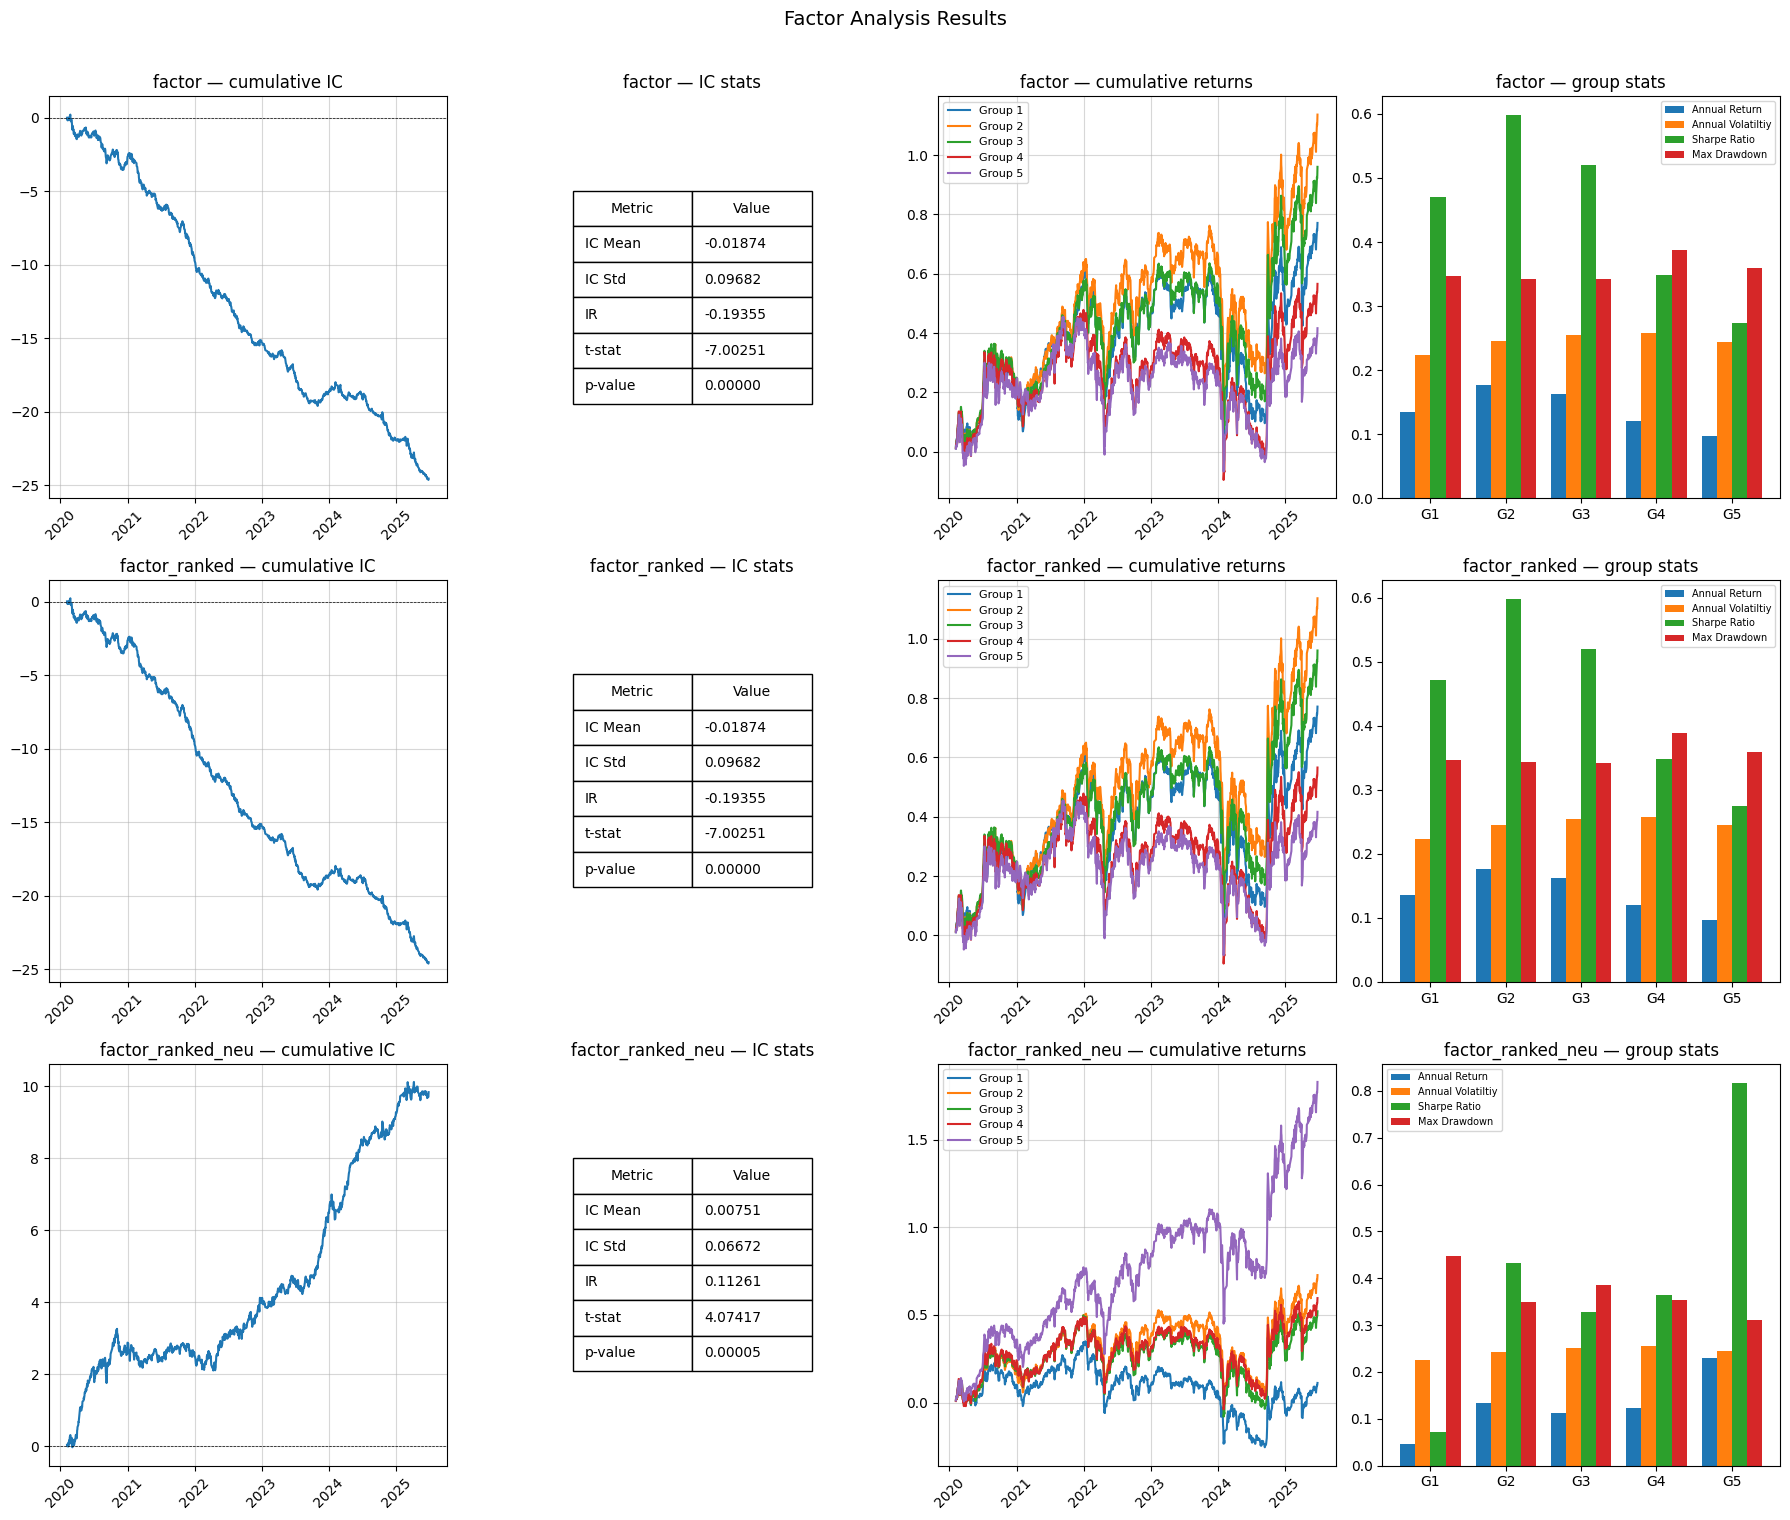

In [17]:
plot_results(ic_info, backtest_results, ['factor','factor_ranked', 'factor_ranked_neu'])